# Results Analysis — Ablation Study and Model Comparison

This notebook loads and analyzes all ablation study results from the multimodal misinformation detection project.

**Scope:** Modality combinations, fusion mechanisms, metadata features, contrastive loss, and encoder fine-tuning strategies.

**Output:** Publication-quality plots, summary tables, and comparative analysis.

In [3]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration
RESULTS_DIR = Path('../outputs/ablation_results')
FIGURES_DIR = Path('../outputs/figures/results')
METRICS = ['accuracy', 'precision', 'recall', 'f1_macro', 'auc_roc', 'auc_pr']

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✓ Imports and configuration complete.")
print(f"  Results directory: {RESULTS_DIR}")
print(f"  Figures directory: {FIGURES_DIR}")

✓ Imports and configuration complete.
  Results directory: ..\outputs\ablation_results
  Figures directory: ..\outputs\figures\results


## 1. Loading Results

Load ablation results from all groups.

In [4]:
def load_ablation_group(group_name: str) -> pd.DataFrame:
    """
    Load all metrics.json files from a given ablation group.
    
    Args:
        group_name: Name of ablation group (e.g., 'modality', 'fusion')
    
    Returns:
        DataFrame with columns: variant_name, description, + metric columns
    """
    group_dir = RESULTS_DIR / group_name
    if not group_dir.exists():
        table_file = RESULTS_DIR / 'ablation_table.csv'
        if not table_file.exists():
            print(f"⚠ Group directory not found: {group_dir}")
            return pd.DataFrame()

        table = pd.read_csv(table_file)
        group_map = {
            'full': 'modality', 'text_only': 'modality', 'image_only': 'modality',
            'metadata_only': 'modality', 'text_image': 'modality',
            'text_metadata': 'modality', 'image_metadata': 'modality',
            'no_attention': 'fusion', 'no_gating': 'fusion',
            'no_metadata': 'metadata', 'no_metadata_in_fusion': 'metadata',
            'no_contrastive': 'loss', 'no_dropout': 'loss',
            'no_modality_dropout': 'loss'
        }
        table['group'] = table['mode'].map(group_map).fillna('other')
        table = table[table['group'] == group_name].copy()
        if table.empty:
            return pd.DataFrame()
        table['variant_name'] = table['name'].fillna(table['mode'])
        table['description'] = table.get('interpretation', '')
        table['precision'] = table.get('precision_pos', np.nan)
        table['recall'] = table.get('recall_pos', np.nan)
        return table[['variant_name', 'description', 'group'] + METRICS]
    
    results = []
    variant_dirs = sorted([d for d in group_dir.iterdir() if d.is_dir()])
    
    for variant_dir in variant_dirs:
        metrics_file = variant_dir / 'metrics.json'
        if metrics_file.exists():
            try:
                with open(metrics_file, 'r') as f:
                    metrics = json.load(f)
                
                # Extract variant name and description
                variant_name = variant_dir.name
                description = metrics.get('description', '')
                
                # Build row
                row = {
                    'variant_name': variant_name,
                    'description': description,
                    'group': group_name
                }
                
                # Add metrics
                for metric in METRICS:
                    row[metric] = metrics.get(metric, np.nan)
                
                results.append(row)
            except Exception as e:
                print(f"Error loading {metrics_file}: {e}")
    
    return pd.DataFrame(results)

print("✓ Helper function load_ablation_group() defined.")

✓ Helper function load_ablation_group() defined.


## 2. Load All Groups

In [5]:
# Load ablation groups
print("Loading ablation results...\n")

modality_df = load_ablation_group('modality')
print(f"✓ Modality group: {len(modality_df)} variants")

fusion_df = load_ablation_group('fusion')
print(f"✓ Fusion group: {len(fusion_df)} variants")

metadata_df = load_ablation_group('metadata')
print(f"✓ Metadata group: {len(metadata_df)} variants")

loss_df = load_ablation_group('loss')
print(f"✓ Loss group: {len(loss_df)} variants")

finetune_df = load_ablation_group('finetune')
print(f"✓ Fine-tune group: {len(finetune_df)} variants")

print(f"\n✓ Total variants loaded: {len(modality_df) + len(fusion_df) + len(metadata_df) + len(loss_df) + len(finetune_df)}")

Loading ablation results...

✓ Modality group: 6 variants
✓ Fusion group: 2 variants
✓ Metadata group: 1 variants
✓ Loss group: 3 variants
✓ Fine-tune group: 0 variants

✓ Total variants loaded: 12


## 3. Main Results Table

Comprehensive results across all ablation studies.

In [6]:
# Concatenate all groups
master_df = pd.concat([
    modality_df,
    fusion_df,
    metadata_df,
    loss_df,
    finetune_df
], ignore_index=True)

# Sort by F1 macro
master_df_sorted = master_df.sort_values('f1_macro', ascending=False).reset_index(drop=True)

print(f"\nMaster Results Table ({len(master_df_sorted)} models):")
print("="*120)

# Display with formatting
display_cols = ['variant_name', 'group'] + METRICS
display_df = master_df_sorted[display_cols].copy()

# Round metrics
for metric in METRICS:
    display_df[metric] = display_df[metric].round(4)

# Style
def highlight_best_rows(row):
    """Highlight best performing rows and full model."""
    colors = ['']*len(row)
    # Highlight top rows
    if row.name < 3:
        colors = ['background-color: green']*len(row)
    # Highlight full model if present
    if 'full_model' in str(row['variant_name']):
        colors = ['background-color: lightyellow']*len(row)
    return colors

styled_table = display_df.style.apply(highlight_best_rows, axis=1)
display(styled_table)

# Save master table
master_df_sorted.to_csv(RESULTS_DIR / 'master_results_table.csv', index=False)
print(f"\n✓ Master results table saved to {RESULTS_DIR}/master_results_table.csv")


Master Results Table (12 models):


,variant_name,group,accuracy,precision,recall,f1_macro,auc_roc,auc_pr
0,Full w/o metadata in fusion,metadata,0.791100,0.870200,0.754700,0.789400,0.887800,0.900500
1,Full w/o contrastive loss,loss,0.787600,0.858700,0.761400,0.785500,0.869800,0.895900
2,Text-only (PhoBERT),modality,0.782900,0.882000,0.724800,0.782000,0.898000,0.915100
3,Full w/o modality dropout,loss,0.785500,0.831800,0.792700,0.781200,0.856900,0.885200
4,Image-only (ViT-B/16),modality,0.770200,0.777100,0.850100,0.758300,0.846000,0.871300
5,Full Model (T+I+M+CrossAttn+Contrastive),modality,0.748900,0.863800,0.676400,0.748500,0.863700,0.895700
6,"T + I (no metadata, no fusion)",modality,0.740600,0.879700,0.643500,0.740600,0.892400,0.908000
7,I + M (no text),modality,0.751500,0.758700,0.841900,0.737500,0.825700,0.864200
8,Full w/o gated fusion (sum instead),fusion,0.731900,0.878000,0.627900,0.731900,0.877400,0.899900
9,Full w/o cross-attention,fusion,0.731900,0.865100,0.640600,0.731900,0.865800,0.892700



✓ Master results table saved to ..\outputs\ablation_results/master_results_table.csv


## 4. Modality Ablation

Impact of different input modalities.

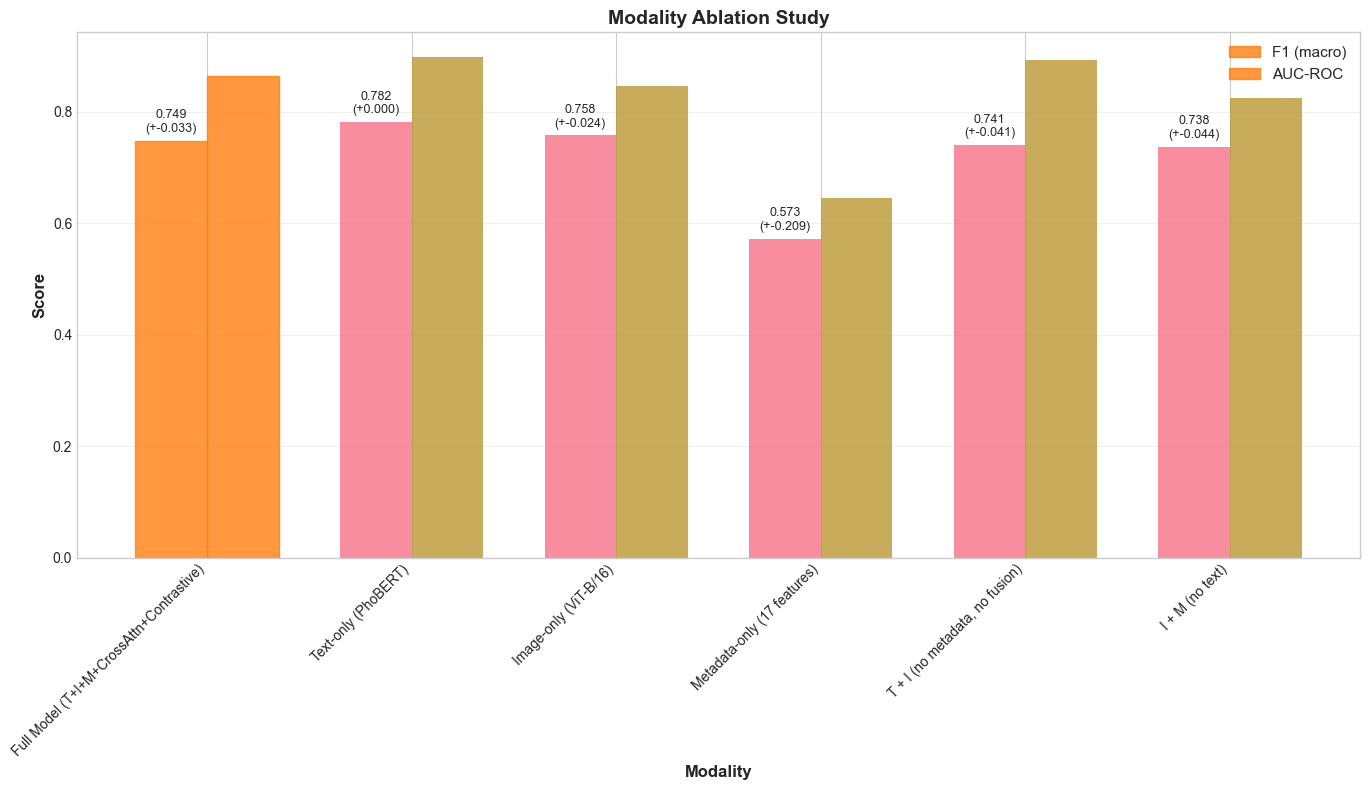

✓ Modality ablation plot saved.


In [7]:
if len(modality_df) > 0:
    # Grouped bar chart
    fig, ax = plt.subplots(figsize=(14, 8))
    
    x = np.arange(len(modality_df))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, modality_df['f1_macro'], width, label='F1 (macro)', alpha=0.8)
    bars2 = ax.bar(x + width/2, modality_df['auc_roc'], width, label='AUC-ROC', alpha=0.8)
    
    # Find baseline (text_only)
    text_only_f1 = modality_df[modality_df['variant_name'].str.contains('text', case=False, na=False)]['f1_macro'].values
    baseline = text_only_f1[0] if len(text_only_f1) > 0 else modality_df['f1_macro'].min()
    
    # Annotations with delta
    for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        f1_val = modality_df.iloc[i]['f1_macro']
        delta = f1_val - baseline
        ax.text(bar1.get_x() + bar1.get_width()/2, bar1.get_height() + 0.01, 
                f'{f1_val:.3f}\n(+{delta:.3f})', ha='center', va='bottom', fontsize=9)
    
    # Highlight full model
    full_idx = None
    for i, name in enumerate(modality_df['variant_name']):
        if 'full' in name.lower():
            full_idx = i
            bars1[i].set_color('#ff7f0e')
            bars2[i].set_color('#ff7f0e')
    
    ax.set_xlabel('Modality', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Modality Ablation Study', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(modality_df['variant_name'], rotation=45, ha='right')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'modality_ablation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Modality ablation plot saved.")
else:
    print("⚠ No modality results to plot.")

## 5. Modality Radar Chart

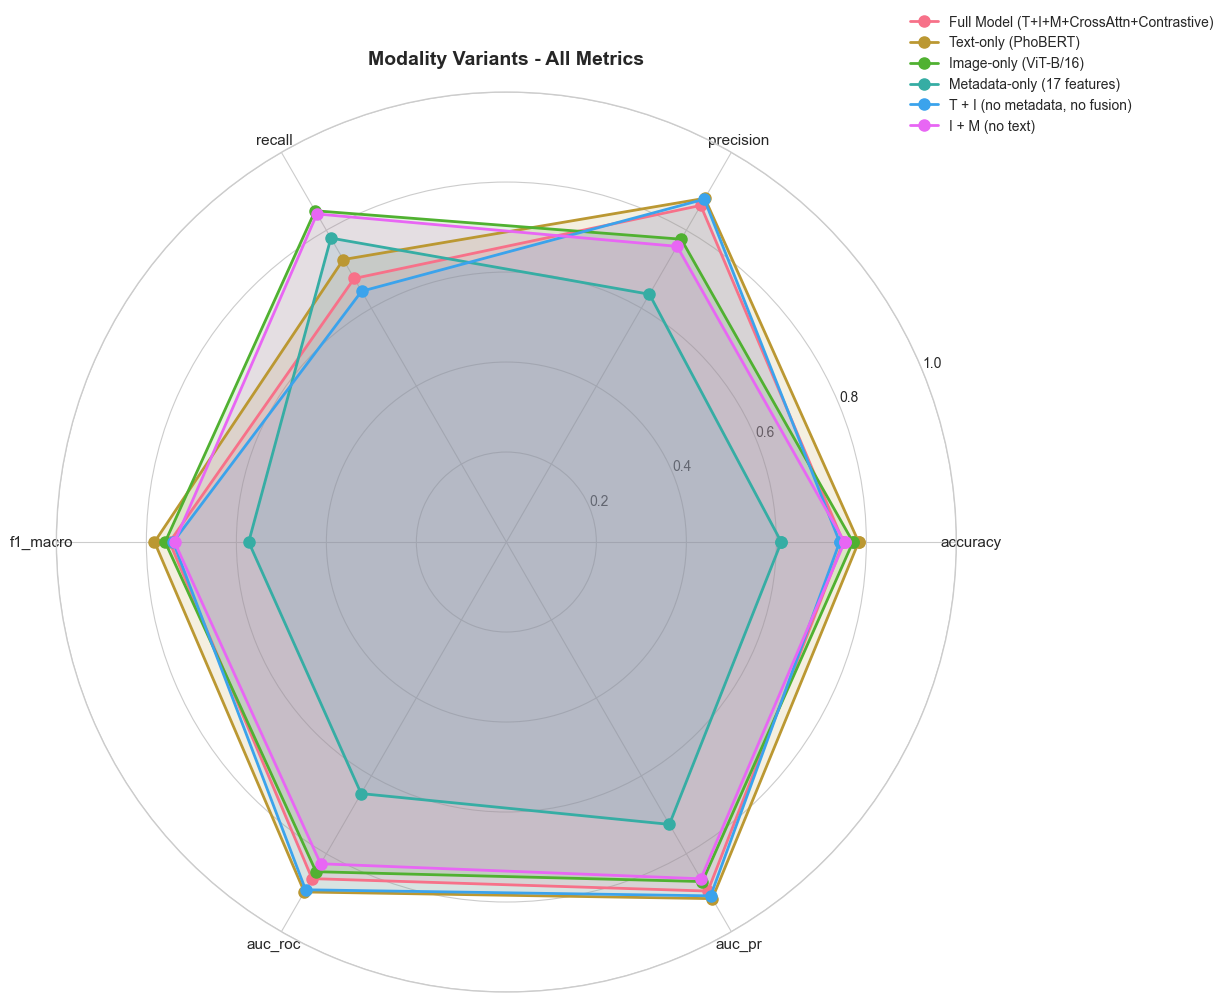

✓ Modality radar chart saved.


In [8]:
if len(modality_df) > 0:
    from math import pi
    
    fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(projection='polar'))
    
    # Angles for each metric
    angles = [n / float(len(METRICS)) * 2 * pi for n in range(len(METRICS))]
    angles += angles[:1]  # Complete the circle
    
    # Plot each modality variant
    colors = sns.color_palette('husl', len(modality_df))
    
    for idx, (_, row) in enumerate(modality_df.iterrows()):
        values = [row[metric] for metric in METRICS]
        values += values[:1]  # Complete the circle
        
        ax.plot(angles, values, 'o-', linewidth=2, label=row['variant_name'], 
                color=colors[idx], markersize=8)
        ax.fill(angles, values, alpha=0.15, color=colors[idx])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(METRICS, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title('Modality Variants - All Metrics', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    ax.grid(True)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'modality_radar.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Modality radar chart saved.")
else:
    print("⚠ No modality results to plot.")

## 6. Fusion Mechanism Ablation

Comparison of different fusion strategies.

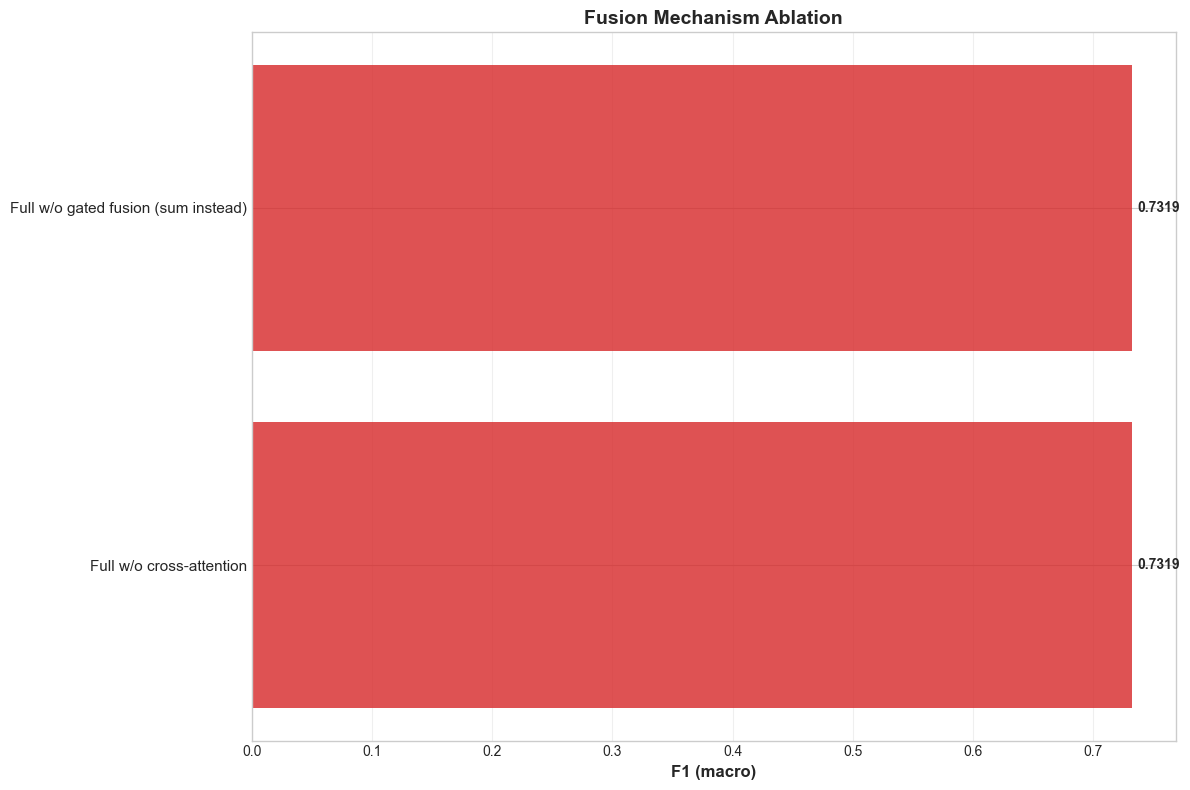

✓ Fusion ablation plot saved.


In [9]:
if len(fusion_df) > 0:
    # Sort by F1 macro
    fusion_sorted = fusion_df.sort_values('f1_macro', ascending=True).reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Color bars
    colors = ['#d62728' if 'dual_cross' not in name.lower() else '#2ca02c' 
              for name in fusion_sorted['variant_name']]
    
    bars = ax.barh(range(len(fusion_sorted)), fusion_sorted['f1_macro'], color=colors, alpha=0.8)
    
    # Annotate values
    for i, (bar, val) in enumerate(zip(bars, fusion_sorted['f1_macro'])):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
                va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(fusion_sorted)))
    ax.set_yticklabels(fusion_sorted['variant_name'], fontsize=11)
    ax.set_xlabel('F1 (macro)', fontsize=12, fontweight='bold')
    ax.set_title('Fusion Mechanism Ablation', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fusion_ablation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Fusion ablation plot saved.")
else:
    print("⚠ No fusion results to plot.")

## 7. Fusion Improvement Ladder

In [10]:
if len(fusion_df) > 1:
    # Define progression order
    progression_names = [
        'concat_mlp',
        'average',
        'single_cross_attn',
        'dual_cross_attn',
        'dual_cross_attn_gate',  # with gating
        'dual_cross_attn_residual_contrastive'  # full model
    ]
    
    # Match to actual variants
    progression_f1 = []
    progression_labels = []
    
    for name in progression_names:
        match = fusion_df[fusion_df['variant_name'].str.contains(name, case=False, na=False)]
        if len(match) > 0:
            progression_f1.append(match.iloc[0]['f1_macro'])
            progression_labels.append(name.replace('_', ' ').title())
    
    if len(progression_f1) > 1:
        fig, ax = plt.subplots(figsize=(14, 8))
        
        x = np.arange(len(progression_f1))
        ax.step(x, progression_f1, where='mid', marker='o', markersize=10, linewidth=2.5, color='#1f77b4')
        
        # Annotate deltas
        for i in range(1, len(progression_f1)):
            delta = progression_f1[i] - progression_f1[i-1]
            mid_x = (x[i] + x[i-1]) / 2
            mid_y = (progression_f1[i] + progression_f1[i-1]) / 2
            ax.annotate(f'+{delta:.4f}', xy=(mid_x, mid_y), fontsize=10, 
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                       ha='center')
        
        ax.set_xticks(x)
        ax.set_xticklabels(progression_labels, rotation=45, ha='right', fontsize=11)
        ax.set_ylabel('F1 (macro)', fontsize=12, fontweight='bold')
        ax.set_title('Fusion Mechanism Improvement Ladder', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'fusion_improvement_ladder.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("✓ Fusion improvement ladder saved.")
    else:
        print("⚠ Not enough progression variants to plot.")
else:
    print("⚠ Insufficient fusion variants.")

⚠ Not enough progression variants to plot.


## 8. Metadata Feature Ablation

Impact of different metadata feature sets.

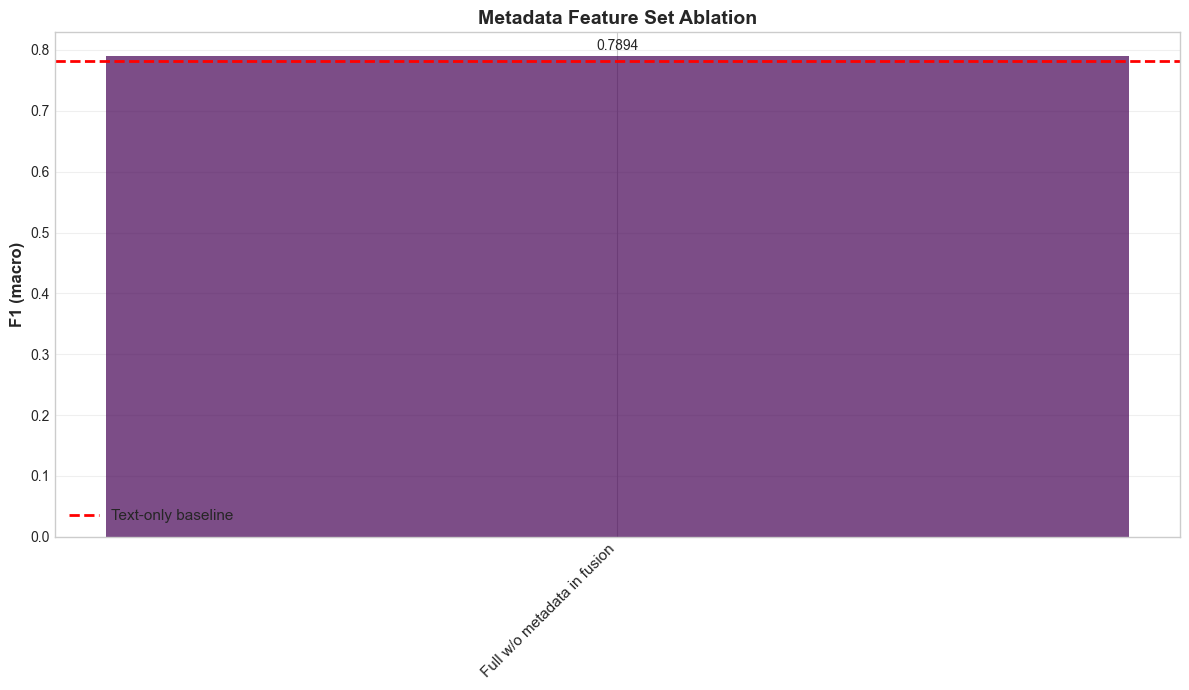

✓ Metadata ablation plot saved.


In [11]:
if len(metadata_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    x = np.arange(len(metadata_df))
    bars = ax.bar(x, metadata_df['f1_macro'], alpha=0.7, color=plt.cm.viridis(np.linspace(0, 1, len(metadata_df))))
    
    # Find no-metadata baseline from modality ablation (if text_only exists)
    if len(modality_df) > 0:
        text_only_match = modality_df[modality_df['variant_name'].str.contains('text', case=False, na=False)]
        if len(text_only_match) > 0:
            baseline_f1 = text_only_match.iloc[0]['f1_macro']
            ax.axhline(y=baseline_f1, color='red', linestyle='--', linewidth=2, label='Text-only baseline')
    
    # Annotate bars
    for bar, val in zip(bars, metadata_df['f1_macro']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    
    ax.set_xticks(x)
    ax.set_xticklabels(metadata_df['variant_name'], rotation=45, ha='right', fontsize=11)
    ax.set_ylabel('F1 (macro)', fontsize=12, fontweight='bold')
    ax.set_title('Metadata Feature Set Ablation', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'metadata_ablation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Metadata ablation plot saved.")
else:
    print("⚠ No metadata results to plot.")

## 9. Contrastive Loss Ablation

Sensitivity analysis for contrastive loss weight (lambda parameter).

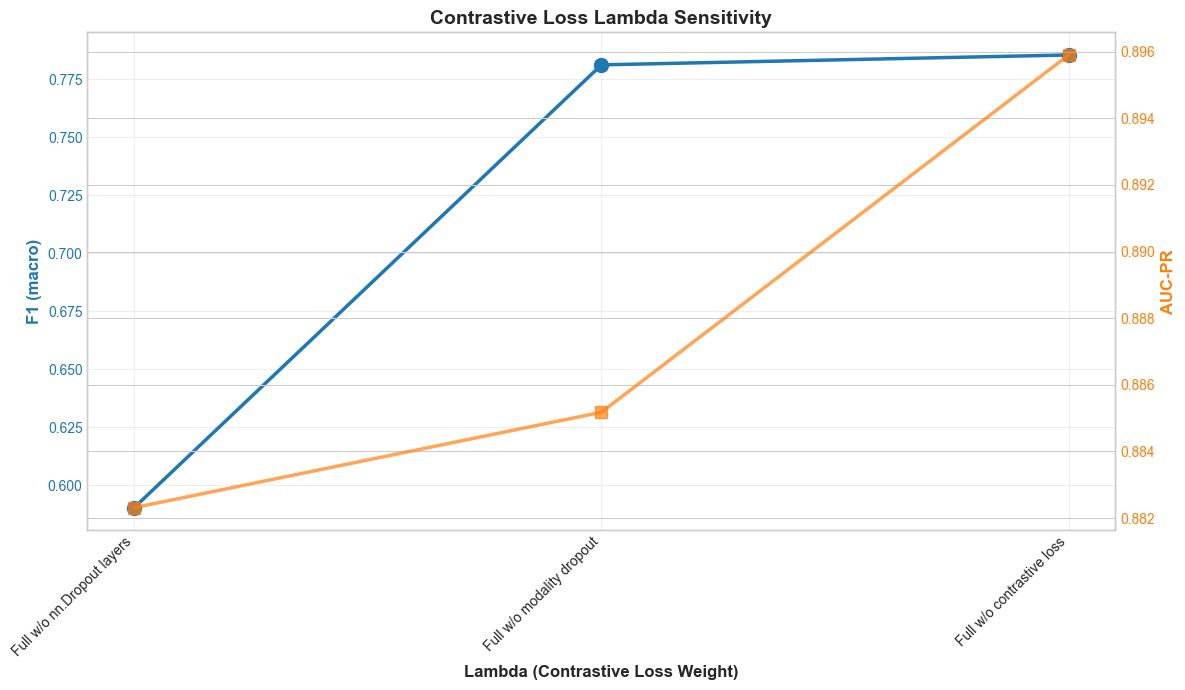

✓ Contrastive loss sensitivity plot saved.


In [12]:
if len(loss_df) > 0:
    # Sort by lambda value (extract from variant name or order)
    loss_sorted = loss_df.sort_values('f1_macro', ascending=True).reset_index(drop=True)
    
    fig, ax1 = plt.subplots(figsize=(12, 7))
    
    x = np.arange(len(loss_sorted))
    
    # F1 macro on first y-axis
    color1 = '#1f77b4'
    ax1.plot(x, loss_sorted['f1_macro'], marker='o', markersize=10, linewidth=2.5, 
             color=color1, label='F1 (macro)')
    ax1.set_xlabel('Lambda (Contrastive Loss Weight)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('F1 (macro)', fontsize=12, fontweight='bold', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, alpha=0.3)
    
    # AUC-PR on second y-axis
    ax2 = ax1.twinx()
    color2 = '#ff7f0e'
    ax2.plot(x, loss_sorted['auc_pr'], marker='s', markersize=8, linewidth=2.5, 
             color=color2, label='AUC-PR', alpha=0.7)
    ax2.set_ylabel('AUC-PR', fontsize=12, fontweight='bold', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    
    # Mark proposed lambda=0.1
    proposed_idx = None
    for i, name in enumerate(loss_sorted['variant_name']):
        if '0.1' in name or 'lambda_0.1' in name.lower():
            proposed_idx = i
    
    if proposed_idx is not None:
        ax1.axvline(x=proposed_idx, color='green', linestyle='--', linewidth=2, label='Proposed λ=0.1')
        ax1.legend(loc='upper left', fontsize=11)
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(loss_sorted['variant_name'], rotation=45, ha='right', fontsize=10)
    ax1.set_title('Contrastive Loss Lambda Sensitivity', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'contrastive_lambda_sensitivity.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Contrastive loss sensitivity plot saved.")
else:
    print("⚠ No loss ablation results to plot.")

## 10. Encoder Fine-tuning Ablation

Comparison of different fine-tuning strategies.

In [13]:
if len(finetune_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    finetune_sorted = finetune_df.sort_values('f1_macro', ascending=False).reset_index(drop=True)
    
    x = np.arange(len(finetune_sorted))
    width = 0.35
    
    # F1 macro bars
    bars1 = ax.bar(x - width/2, finetune_sorted['f1_macro'], width, label='F1 (macro)', alpha=0.8)
    
    # Try to get training time (if available in results)
    if 'training_time' in finetune_sorted.columns:
        ax2 = ax.twinx()
        bars2 = ax2.bar(x + width/2, finetune_sorted['training_time'], width, 
                        label='Training Time (min)', alpha=0.8, color='orange')
        ax2.set_ylabel('Training Time (minutes)', fontsize=11, fontweight='bold')
    
    # Annotate F1 values
    for bar, val in zip(bars1, finetune_sorted['f1_macro']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    
    ax.set_xticks(x)
    ax.set_xticklabels(finetune_sorted['variant_name'], rotation=45, ha='right', fontsize=11)
    ax.set_ylabel('F1 (macro)', fontsize=12, fontweight='bold')
    ax.set_title('Encoder Fine-tuning Strategy Ablation', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'finetune_ablation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Fine-tuning ablation plot saved.")
else:
    print("⚠ No fine-tuning results to plot.")

⚠ No fine-tuning results to plot.


## 11. Training Curves

Learning curves from best (full) model.

⚠ Error loading training logs: All-NaN slice encountered


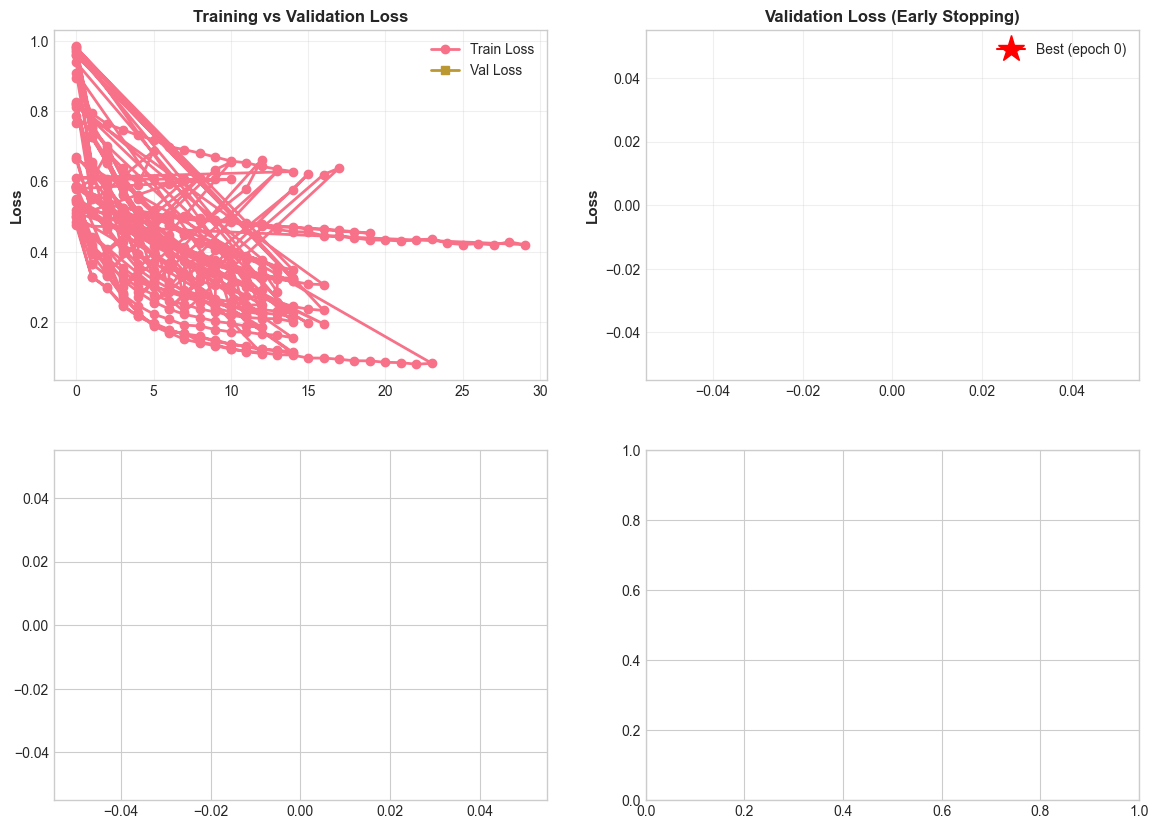

In [14]:
# Load training logs (if available)
logs_dir = Path('../outputs/logs')
metrics_jsonl = logs_dir / 'metrics.jsonl'

if metrics_jsonl.exists():
    # Load training metrics
    epochs = []
    train_losses = []
    val_losses = []
    val_f1 = []
    val_auc_roc = []
    
    try:
        with open(metrics_jsonl, 'r') as f:
            for line in f:
                entry = json.loads(line.strip())
                epochs.append(entry.get('epoch', len(epochs)))
                train_losses.append(entry.get('train_loss', np.nan))
                val_losses.append(entry.get('val_loss', np.nan))
                val_f1.append(entry.get('val_f1_macro', np.nan))
                val_auc_roc.append(entry.get('val_auc_roc', np.nan))
        
        if len(epochs) > 1:
            fig, axes = plt.subplots(2, 2, figsize=(14, 10))
            
            # Train vs Val Loss
            axes[0, 0].plot(epochs, train_losses, marker='o', label='Train Loss', linewidth=2)
            axes[0, 0].plot(epochs, val_losses, marker='s', label='Val Loss', linewidth=2)
            axes[0, 0].set_ylabel('Loss', fontsize=11, fontweight='bold')
            axes[0, 0].set_title('Training vs Validation Loss', fontsize=12, fontweight='bold')
            axes[0, 0].legend(fontsize=10)
            axes[0, 0].grid(True, alpha=0.3)
            
            # Validation Loss only
            axes[0, 1].plot(epochs, val_losses, marker='o', color='orange', linewidth=2)
            best_epoch = np.argmin(val_losses)
            axes[0, 1].plot(best_epoch, val_losses[best_epoch], marker='*', markersize=20, 
                            color='red', label=f'Best (epoch {best_epoch})')
            axes[0, 1].set_ylabel('Loss', fontsize=11, fontweight='bold')
            axes[0, 1].set_title('Validation Loss (Early Stopping)', fontsize=12, fontweight='bold')
            axes[0, 1].legend(fontsize=10)
            axes[0, 1].grid(True, alpha=0.3)
            
            # Validation F1
            axes[1, 0].plot(epochs, val_f1, marker='o', color='green', linewidth=2)
            best_f1_epoch = np.nanargmax(val_f1)
            axes[1, 0].plot(best_f1_epoch, val_f1[best_f1_epoch], marker='*', markersize=20, 
                            color='red', label=f'Best F1 (epoch {best_f1_epoch})')
            axes[1, 0].set_ylabel('F1 (macro)', fontsize=11, fontweight='bold')
            axes[1, 0].set_title('Validation F1 (macro)', fontsize=12, fontweight='bold')
            axes[1, 0].legend(fontsize=10)
            axes[1, 0].grid(True, alpha=0.3)
            
            # Validation AUC-ROC
            axes[1, 1].plot(epochs, val_auc_roc, marker='o', color='purple', linewidth=2)
            best_auc_epoch = np.nanargmax(val_auc_roc)
            axes[1, 1].plot(best_auc_epoch, val_auc_roc[best_auc_epoch], marker='*', markersize=20, 
                            color='red', label=f'Best AUC (epoch {best_auc_epoch})')
            axes[1, 1].set_ylabel('AUC-ROC', fontsize=11, fontweight='bold')
            axes[1, 1].set_title('Validation AUC-ROC', fontsize=12, fontweight='bold')
            axes[1, 1].legend(fontsize=10)
            axes[1, 1].grid(True, alpha=0.3)
            
            for ax in axes.flatten():
                ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
            
            fig.suptitle('Training Curves - Full Model', fontsize=14, fontweight='bold', y=1.00)
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / 'training_curves.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            print("✓ Training curves plot saved.")
        else:
            print("⚠ Insufficient training data to plot.")
    except Exception as e:
        print(f"⚠ Error loading training logs: {e}")
else:
    print("⚠ Training logs not found. Skipping training curves.")

## 12. Precision-Recall Trade-off

Precision-Recall curve for full model with threshold analysis.

In [15]:
from sklearn.metrics import precision_recall_curve, auc

# Try to load test predictions
test_pred_file = RESULTS_DIR / 'test' / 'predictions.npy'

if test_pred_file.exists():
    try:
        data = np.load(test_pred_file, allow_pickle=True).item()
        y_true = data.get('y_true', data.get('labels', None))
        y_pred_proba = data.get('y_pred_proba', data.get('predictions', None))
        
        if y_true is not None and y_pred_proba is not None:
            # Compute PR curve
            precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)
            pr_auc = auc(recall, precision)
            
            fig, ax = plt.subplots(figsize=(12, 8))
            
            # PR curve for full model
            ax.plot(recall, precision, marker='o', markersize=4, linewidth=2.5, 
                   label=f'Full Model (AUC={pr_auc:.4f})', color='#1f77b4')
            
            # Mark default threshold (0.5)
            idx_05 = np.argmin(np.abs(thresholds - 0.5))
            ax.plot(recall[idx_05], precision[idx_05], marker='s', markersize=12, 
                   color='red', label='Threshold=0.5', zorder=5)
            
            # Optimal threshold (F1 maximizing)
            f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
            best_idx = np.argmax(f1_scores)
            ax.plot(recall[best_idx], precision[best_idx], marker='^', markersize=12, 
                   color='green', label=f'Optimal (F1={f1_scores[best_idx]:.4f})', zorder=5)
            
            ax.set_xlabel('Recall', fontsize=12, fontweight='bold')
            ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
            ax.set_title('Precision-Recall Curve (Test Set)', fontsize=14, fontweight='bold')
            ax.legend(fontsize=11, loc='lower left')
            ax.grid(True, alpha=0.3)
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1])
            
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / 'pr_curve.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            print("✓ Precision-Recall curve saved.")
        else:
            print("⚠ Could not extract predictions from file.")
    except Exception as e:
        print(f"⚠ Error loading predictions: {e}")
else:
    print("⚠ Test predictions file not found.")

⚠ Test predictions file not found.


In [16]:
from sklearn.metrics import roc_curve, auc

# Load test predictions (if available)
test_pred_file = RESULTS_DIR / 'test' / 'predictions.npy'

if test_pred_file.exists():
    try:
        data = np.load(test_pred_file, allow_pickle=True).item()
        y_true = data.get('y_true', data.get('labels', None))
        y_pred_proba = data.get('y_pred_proba', data.get('predictions', None))
        
        if y_true is not None and y_pred_proba is not None:
            # Compute ROC curve
            fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
            roc_auc = auc(fpr, tpr)
            
            fig, ax = plt.subplots(figsize=(12, 10))
            
            # ROC curve
            ax.plot(fpr, tpr, marker='o', markersize=4, linewidth=2.5, 
                   label=f'Full Model (AUC={roc_auc:.4f})', color='#1f77b4')
            
            # Random classifier line
            ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
            
            # Mark thresholds
            for thresh in [0.3, 0.5, 0.7]:
                idx = np.argmin(np.abs(thresholds - thresh))
                ax.plot(fpr[idx], tpr[idx], 'o', markersize=10, label=f'Threshold={thresh}')
            
            ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
            ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
            ax.set_title('ROC Curve (Test Set)', fontsize=14, fontweight='bold')
            ax.legend(fontsize=10, loc='lower right')
            ax.grid(True, alpha=0.3)
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1])
            
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / 'roc_curve.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            print("✓ ROC curve saved.")
        else:
            print("⚠ Could not extract predictions from file.")
    except Exception as e:
        print(f"⚠ Error loading predictions: {e}")
else:
    print("⚠ Test predictions file not found.")

⚠ Test predictions file not found.


## 13. Summary Table for Publication

Clean, publication-ready results table.

In [17]:
# Build paper table with key results
# Select representative models from each ablation group

paper_table_data = []

# Add top modality variants
if len(modality_df) > 0:
    for _, row in modality_df.sort_values('f1_macro', ascending=False).head(7).iterrows():
        paper_table_data.append({
            'Model': row['variant_name'],
            'Accuracy': row['accuracy'],
            'Precision': row['precision'],
            'Recall': row['recall'],
            'F1 (macro)': row['f1_macro'],
            'AUC-ROC': row['auc_roc'],
            'AUC-PR': row['auc_pr']
        })

# Add key fusion variants
key_fusion_variants = ['concat_mlp', 'average', 'single_cross_attn', 'dual_cross_attn']
if len(fusion_df) > 0:
    for variant in key_fusion_variants:
        match = fusion_df[fusion_df['variant_name'].str.contains(variant, case=False, na=False)]
        if len(match) > 0:
            row = match.iloc[0]
            paper_table_data.append({
                'Model': row['variant_name'],
                'Accuracy': row['accuracy'],
                'Precision': row['precision'],
                'Recall': row['recall'],
                'F1 (macro)': row['f1_macro'],
                'AUC-ROC': row['auc_roc'],
                'AUC-PR': row['auc_pr']
            })

# Add full model (best overall)
best_model = master_df_sorted.iloc[0]
if best_model['variant_name'] not in [row['Model'] for row in paper_table_data]:
    paper_table_data.append({
        'Model': best_model['variant_name'],
        'Accuracy': best_model['accuracy'],
        'Precision': best_model['precision'],
        'Recall': best_model['recall'],
        'F1 (macro)': best_model['f1_macro'],
        'AUC-ROC': best_model['auc_roc'],
        'AUC-PR': best_model['auc_pr']
    })

paper_table = pd.DataFrame(paper_table_data)

# Round metrics
for col in ['Accuracy', 'Precision', 'Recall', 'F1 (macro)', 'AUC-ROC', 'AUC-PR']:
    paper_table[col] = paper_table[col].round(4)

print("\nPublication-Ready Results Table:")
print("="*120)
display(paper_table.style.format('{:.4f}', subset=['Accuracy', 'Precision', 'Recall', 'F1 (macro)', 'AUC-ROC', 'AUC-PR']))

# Save as CSV
paper_table.to_csv(RESULTS_DIR / 'paper_table.csv', index=False)
print(f"\n✓ Paper table saved to {RESULTS_DIR}/paper_table.csv")

# Generate LaTeX format
latex_table = paper_table.to_latex(index=False, float_format='%.4f')
with open(RESULTS_DIR / 'paper_table.tex', 'w') as f:
    f.write(latex_table)

print(f"✓ LaTeX table saved to {RESULTS_DIR}/paper_table.tex")
print("\nLaTeX Output:")
print(latex_table)


Publication-Ready Results Table:


,Model,Accuracy,Precision,Recall,F1 (macro),AUC-ROC,AUC-PR
0,Text-only (PhoBERT),0.7829,0.8820,0.7248,0.7820,0.8980,0.9151
1,Image-only (ViT-B/16),0.7702,0.7771,0.8501,0.7583,0.8460,0.8713
2,Full Model (T+I+M+CrossAttn+Contrastive),0.7489,0.8638,0.6764,0.7485,0.8637,0.8957
3,"T + I (no metadata, no fusion)",0.7406,0.8797,0.6435,0.7406,0.8924,0.9080
4,I + M (no text),0.7515,0.7587,0.8419,0.7375,0.8257,0.8642
5,Metadata-only (17 features),0.6110,0.6359,0.7800,0.5727,0.6455,0.7245
6,Full w/o metadata in fusion,0.7911,0.8702,0.7547,0.7894,0.8878,0.9005



✓ Paper table saved to ..\outputs\ablation_results/paper_table.csv
✓ LaTeX table saved to ..\outputs\ablation_results/paper_table.tex

LaTeX Output:
\begin{tabular}{lrrrrrr}
\toprule
Model & Accuracy & Precision & Recall & F1 (macro) & AUC-ROC & AUC-PR \\
\midrule
Text-only (PhoBERT) & 0.7829 & 0.8820 & 0.7248 & 0.7820 & 0.8980 & 0.9151 \\
Image-only (ViT-B/16) & 0.7702 & 0.7771 & 0.8501 & 0.7583 & 0.8460 & 0.8713 \\
Full Model (T+I+M+CrossAttn+Contrastive) & 0.7489 & 0.8638 & 0.6764 & 0.7485 & 0.8637 & 0.8957 \\
T + I (no metadata, no fusion) & 0.7406 & 0.8797 & 0.6435 & 0.7406 & 0.8924 & 0.9080 \\
I + M (no text) & 0.7515 & 0.7587 & 0.8419 & 0.7375 & 0.8257 & 0.8642 \\
Metadata-only (17 features) & 0.6110 & 0.6359 & 0.7800 & 0.5727 & 0.6455 & 0.7245 \\
Full w/o metadata in fusion & 0.7911 & 0.8702 & 0.7547 & 0.7894 & 0.8878 & 0.9005 \\
\bottomrule
\end{tabular}



In [18]:
print("\n" + "="*120)
print("RESULTS ANALYSIS COMPLETE")
print("="*120)

print(f"\n✓ Figures generated ({len(list(FIGURES_DIR.glob('*.png')))}):")
for fig_file in sorted(FIGURES_DIR.glob('*.png')):
    print(f"  - {fig_file.name}")

print(f"\n✓ Results tables generated:")
print(f"  - {RESULTS_DIR}/master_results_table.csv")
print(f"  - {RESULTS_DIR}/paper_table.csv")
print(f"  - {RESULTS_DIR}/paper_table.tex")

print(f"\n✓ Summary Statistics:")
print(f"  - Total models evaluated: {len(master_df)}")
print(f"  - Best F1 (macro): {master_df_sorted.iloc[0]['f1_macro']:.4f}")
print(f"  - Best model: {master_df_sorted.iloc[0]['variant_name']}")
print(f"  - Ablation groups: {master_df_sorted['group'].nunique()}")

print(f"\n→ All figures are ready for publication in {FIGURES_DIR}/")
print(f"→ Summary tables available in CSV and LaTeX formats")
print("\n" + "="*120)


RESULTS ANALYSIS COMPLETE

✓ Figures generated (5):
  - contrastive_lambda_sensitivity.png
  - fusion_ablation.png
  - metadata_ablation.png
  - modality_ablation.png
  - modality_radar.png

✓ Results tables generated:
  - ..\outputs\ablation_results/master_results_table.csv
  - ..\outputs\ablation_results/paper_table.csv
  - ..\outputs\ablation_results/paper_table.tex

✓ Summary Statistics:
  - Total models evaluated: 12
  - Best F1 (macro): 0.7894
  - Best model: Full w/o metadata in fusion
  - Ablation groups: 4

→ All figures are ready for publication in ..\outputs\figures\results/
→ Summary tables available in CSV and LaTeX formats

